# 3 Apr 2026
- basic notebook that samples IPTA MDC1 in linspharm basis using discovery -- new specspat formalism

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import re
import inspect
import types
import typing
from collections.abc import Iterable
import functools
from pprint import pprint
import time

import numpy as np
import scipy.interpolate as si
import jax
from jax.scipy import stats as jss
import jax.numpy as jnp

from discovery import matrix
from discovery import const
import discovery as ds
import discovery.samplers.numpyro as ds_numpyro
import glob
import discovery.anis_coefficients as dac
import matplotlib.pyplot as plt
from discovery.glgp_specspat import makeglobalgp_fourier_specspat

/home/levis/miniforge3/envs/jhp_disco/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# sampling items
from numpyro import infer, distributions as dist
import numpyro
import scipy.stats as stats
import healpy as hp
from corner import corner
#import maps
import pandas as pd
import pyarrow.feather as feather
import enterprise.signals.anis_coefficients as ac
from PTMCMCSampler import PTMCMCSampler
import matplotlib.patches as mpatches

Optional mpi4py package is not installed.  MPI support is not available.


/home/levis/miniforge3/envs/jhp_disco/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from defiant.extra import mdc1_utils
mdcpsrs, injparams = mdc1_utils.get_MDC1_psrs(use_pickle=True)

## broadband analysis

In [5]:
# psrs = mdcpsrs
# T = ds.getspan(psrs)
# comps = 6 # freq components
# lmx = 6
# nsi=1

# psrpos = np.array([p.pos for p in psrs])

# lsphorf = dac.get_linspharm_orf(psrpos, lmax=lmx)

# glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.powerlaw],
#                                     [[functools.partial(lsphorf, c00=np.sqrt(4*np.pi))]],
#                                     components=comps, T=T, name='gw', nbasis=[[(lmx+1)**2-1]])


# # m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
# #                                              ds.makenoise_measurement_simple(psr),
# #                                              ds.makegp_timing(psr, svd=True)]) for psr in psrs],
# #                        commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
# #                        globalgp = glgp_mdc)

# m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True),
#                                              ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
#                                              globalgp = glgp_mdc)


# mdc_jlogl = jax.jit(m_mdc.logL)

In [7]:
psrs = mdcpsrs
T = ds.getspan(psrs)
comps = 6 # freq components
lmx = 6
nsi=1
nclms = (lmx+1)**2-1

ndict = {f'{p.name}_efac': 1.0 for p in psrs}
ndict.update({f'{p.name}_log10_t2equad': -7 for p in psrs})


psrpos = np.array([p.pos for p in psrs])

lsphorf = dac.get_linspharm_orf(psrpos, lmax=lmx)

glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.powerlaw],
                                    [[functools.partial(lsphorf, c00=np.sqrt(4*np.pi))]],
                                    components=comps, T=T, name='gw', nbasis=[[(lmx+1)**2-1]])


m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                                             ds.makenoise_measurement_simple(psr, noisedict=ndict),
                                             ds.makegp_timing(psr, svd=True)]) for psr in psrs],
                       commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
                       globalgp = glgp_mdc)

# m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True),
#                                              ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
#                                              globalgp = glgp_mdc)


mdc_jlogl = jax.jit(m_mdc.logL)

@jax.jit
def constrn_like(params):
    paramdict = {f'{p.name}_rednoise_gamma':1 for p in mdcpsrs}
    paramdict.update({f'{p.name}_rednoise_log10_A':-18 for p in mdcpsrs})
    paramdict['gw_clm(48)'] = params[:nclms]
    paramdict['gw_gamma'] = params[-2]
    paramdict['gw_log10_A'] = params[-1]
    return m_mdc.logL(paramdict)
    

In [8]:
# psrs = mdcpsrs
# T = ds.getspan(psrs)
# comps = 6 # freq components
# lmx = 6
# nsi=1
# nclms = (lmx+1)**2-1

# ndict = {f'{p.name}_efac': 1.0 for p in psrs}
# ndict.update({f'{p.name}_log10_t2equad': -7 for p in psrs})

# psrpos = np.array([p.pos for p in psrs])

# lsphorf = dac.get_linspharm_orf(psrpos, lmax=lmx)

# glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.powerlaw],
#                                     [[functools.partial(lsphorf, c00=np.sqrt(4*np.pi))]],
#                                     components=comps, T=T, name='gw', nbasis=[[nclms]])

# m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals,
#                                              ds.makenoise_measurement_simple(psr, noisedict=ndict),
#                                              ds.makegp_timing(psr, svd=True),
#                                              ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
#                                              globalgp = glgp_mdc)


# @jax.jit
# def constrn_like(params):
#     paramdict = {f'{p.name}_rednoise_gamma':1 for p in mdcpsrs}
#     paramdict.update({f'{p.name}_rednoise_log10_A':-18 for p in mdcpsrs})
#     paramdict['gw_clm(48)'] = params[:nclms]
#     paramdict['gw_gamma'] = params[-2]
#     paramdict['gw_log10_A'] = params[-1]
#     return m_mdc.logL(paramdict)
    

In [9]:
tstpars = jnp.zeros(50)
tstpars = tstpars.at[-2].set(13/3)
tstpars = tstpars.at[-1].set(-16)

constrn_like(tstpars)

Array(-78083.70989644, dtype=float64)

In [10]:
%timeit constrn_like(tstpars).block_until_ready()

4.58 ms ± 53 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [11]:
l10apri = lambda x: jss.uniform.logpdf(x, -18, 6)
gampri = lambda x: jss.uniform.logpdf(x, 0, 7)
clmpri = lambda x: jss.uniform.logpdf(x, -5, 10)

@jax.jit
def priorfunc(params):
    clms = params[:nclms]
    gamma = params[-2]
    log10A = params[-1]
    clmprival = jnp.sum(clmpri(clms))
    gamprival = gampri(gamma)
    l10Aprival = l10apri(log10A)
    fullpri = clmprival + gamprival + l10Aprival
    return fullpri



In [12]:
%timeit priorfunc(tstpars).block_until_ready()

16.3 μs ± 192 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [11]:
prigrad = jax.grad(priorfunc)
likgrad = jax.grad(constrn_like)

# prigradjump = lambda x: (priorfunc(x), prigrad(x))
# prigradlike = lambda x: (constrn_like(x), likgrad(x))

def prigradjump(x):
    return np.float64(priorfunc(x)).item(), np.array(prigrad(x))

def likegradjump(x):
    return np.float64(constrn_like(x)).item(), np.array(likgrad(x))

In [20]:
initcov = np.eye(50) * 0.01
sampler = PTMCMCSampler.PTSampler(ndim=50, logl=constrn_like, logp=priorfunc,
                                   logl_grad=likegradjump, logp_grad=prigradjump, cov=initcov,
                                   outDir='./chains/gradjptst/', resume=True)

In [21]:
sampler.sample(Niter=100000, p0=np.array(tstpars),
               SCAMweight=25, AMweight=25, DEweight=50)

Resuming run from chain file ./chains/gradjptst//chain_1.txt
Resuming with 501 samples from file representing 5001 original samples
Finished 10.00 percent (5.25 percent of new work) in 455.701869 s Acceptance rate = 0.665998Adding DE jump with weight 50
Finished 100.00 percent (100.00 percent of new work) in 5003.593255 s Acceptance rate = 0.59101
Run Complete


## Looking at the chain

In [13]:
chn = np.loadtxt('/home/levis/ipta_aniso_datachallenge/examples/chains/gradjptst/chain_1.txt')

In [14]:
chn.shape

(10001, 54)

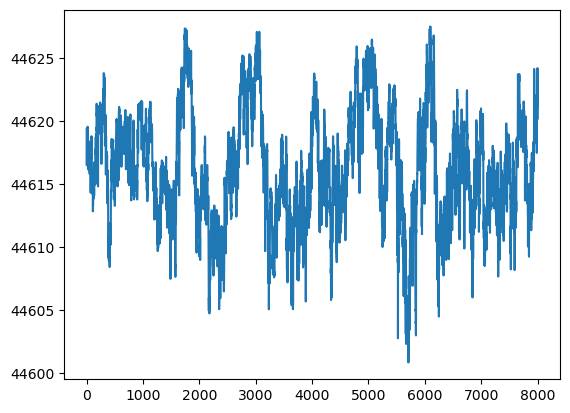

In [15]:
plt.plot(chn[2000:, -4])

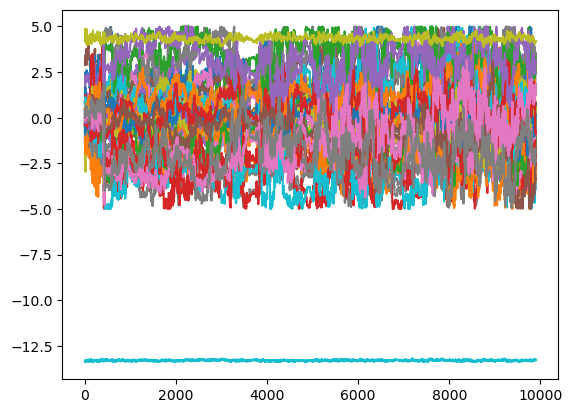

In [16]:
for i in range(50):
    plt.plot(chn[100:, i])

In [17]:
truevals = np.zeros(50)
truevals[-2] = 13/3
truevals[-1] = -13.301029995663981

In [25]:
#corner(chn[2000:, :-4], truths=truevals);

In [18]:
injparams

{'gw_log10_A': np.float64(-13.301029995663981), 'gw_gamma': 4.333333333333333}

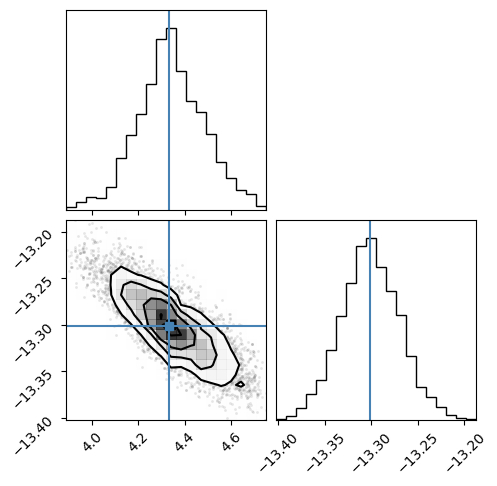

In [19]:
corner(chn[2000:, -6:-4], truths=[13/3, -13.301029995663981]);

In [22]:
holdangpow = np.zeros((1000, lmx))
for i in range(1000):
    holdangpow[i,:] = dac.clm2angpowspec(chn[3000:, :nclms][i], lmax=lmx)

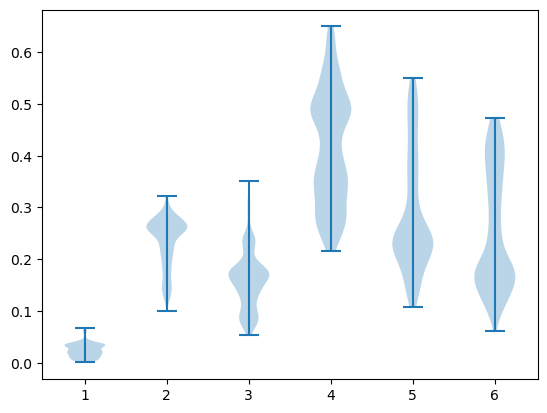

In [24]:
plt.violinplot(holdangpow/(4*np.pi), positions=np.arange(1, lmx+1));